In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../../src/')
from build_model import resnet50_yichen
from train_functions import train_epochs
from dataset_functions import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid, verify_image_in_hdf5_file
from visualization_functions import show_images

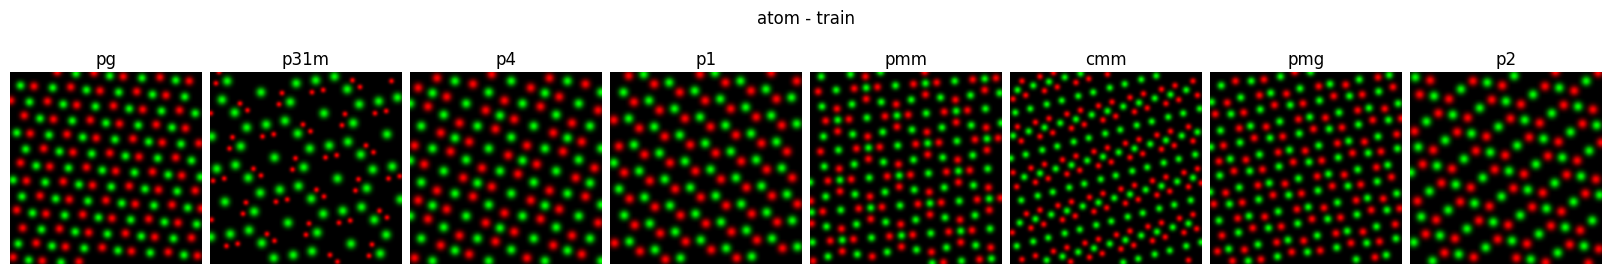

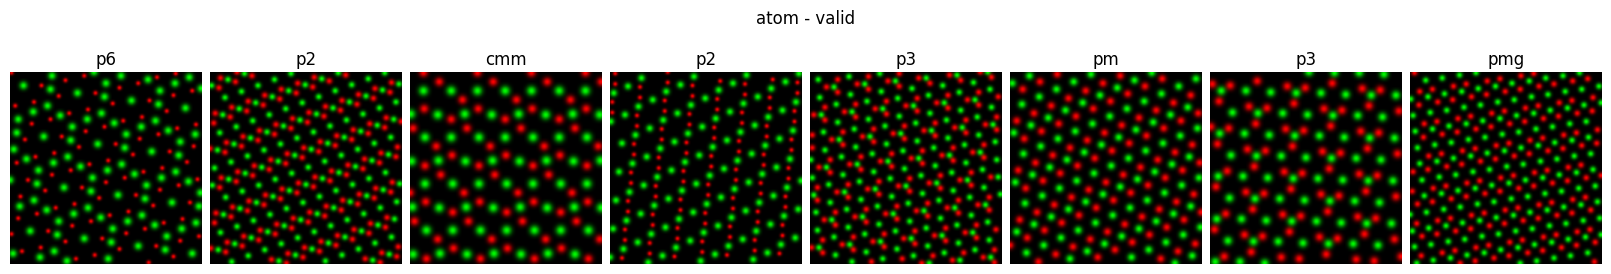

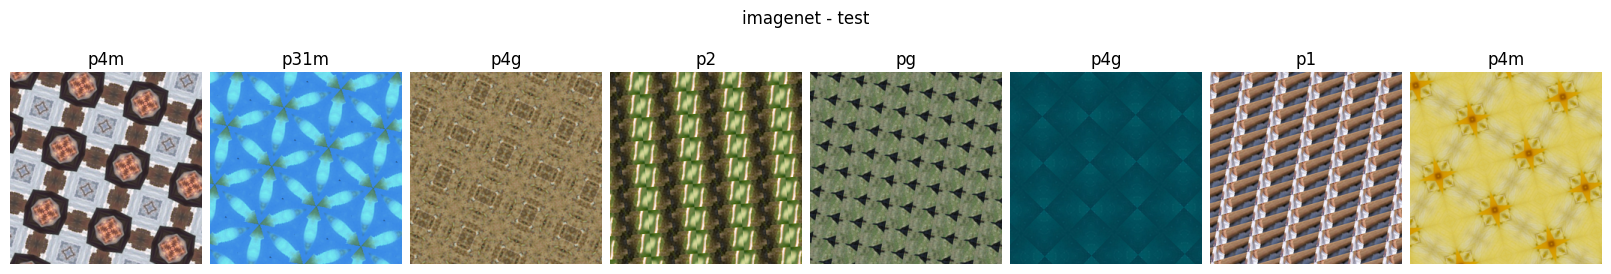

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

# imagenet - train
train_dl = DataLoader(train_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(train_dl, label_converter=label_converter, title='atom - train')

# imagenet - valid
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter, title='atom - valid')

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(test_dl, label_converter=label_converter, title='imagenet - test')

In [3]:
model = resnet50_yichen(in_channels=3, n_classes=17, pretrained=False)
print(model(torch.randn(2,3,256,256)).shape)

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.Size([2, 17])


# train

In [4]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'model': 'resnet50_yichen',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'Train_Atom-CrossValidate_ImageNet'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [5]:
device = torch.device('cuda:1')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}', tracking=True)

Epoch: 1/50


100%|██████████| 134/134 [01:46<00:00,  1.25it/s]


Training: Loss: 2.9592, Accuracy: 8.0738%, Time: 1.7805mins


100%|██████████| 34/34 [00:11<00:00,  2.88it/s]


Validation : Loss : 2.5966, Accuracy: 15.4300%, Time: 0.20mins


...

Training: Loss: 0.0007, Accuracy: 100.0000%, Time: 1.7702mins


100%|██████████| 34/34 [00:11<00:00,  2.96it/s]


Validation : Loss : 0.1014, Accuracy: 98.0950%, Time: 0.19mins


100%|██████████| 167/167 [00:57<00:00,  2.90it/s]


Validation : Loss : 11.5369, Accuracy: 6.8490%, Time: 0.96mins


# analyze

In [6]:
from analysis_functions import confusion_matrix, plot_cm

In [7]:
# model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

# NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
# symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
#                     'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [8]:
# device = torch.device('cuda:0')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'{NAME}-train_cm.npy', cm)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [00:45<00:00,  2.92it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,4632.0,4725.0,4698.0,4719.0,4686.0,4661.0,4739.0,4679.0,4694.0,4711.0,4724.0,4654.0,4725.0,4728.0,4763.0,4756.0,4706.0


Accuracy for these batches: 0.9999875


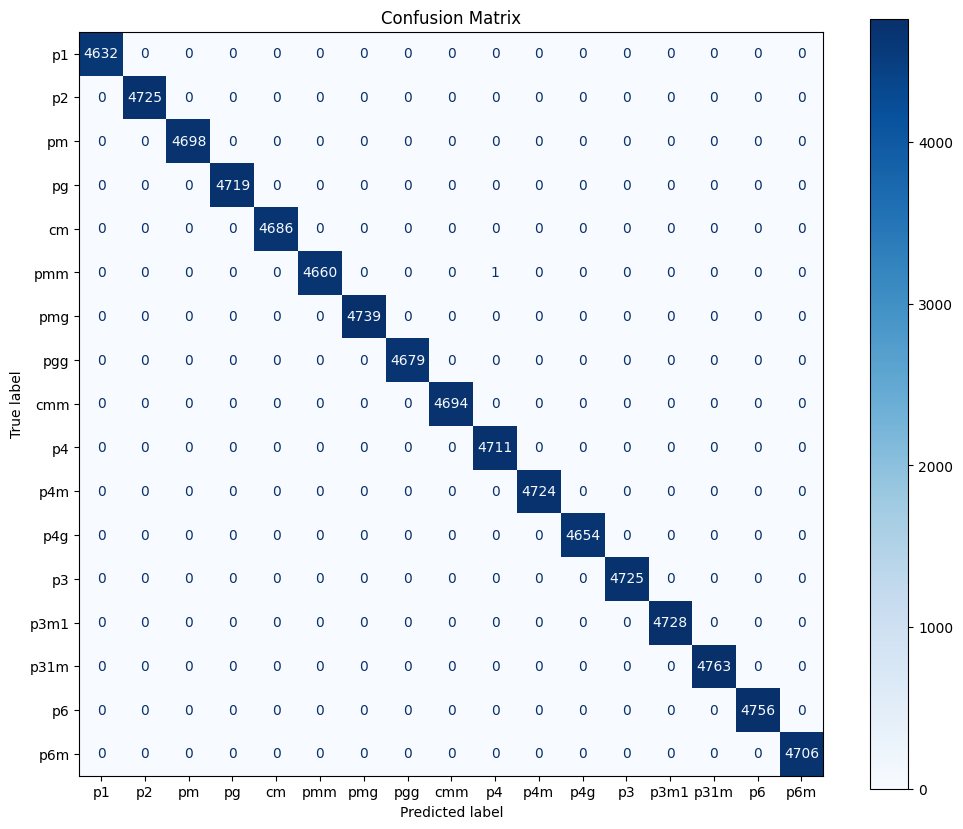

In [9]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=f'{NAME}-train', title=None, style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [10]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'{NAME}-valid_cm.npy', cm)


  0%|          | 0/34 [00:00<?, ?it/s]

100%|██████████| 34/34 [00:11<00:00,  2.86it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,1249.0,1161.0,1184.0,1160.0,1195.0,1217.0,1142.0,1204.0,1191.0,1170.0,1158.0,1229.0,1157.0,1156.0,1117.0,1130.0,1180.0


Accuracy for these batches: 0.98095


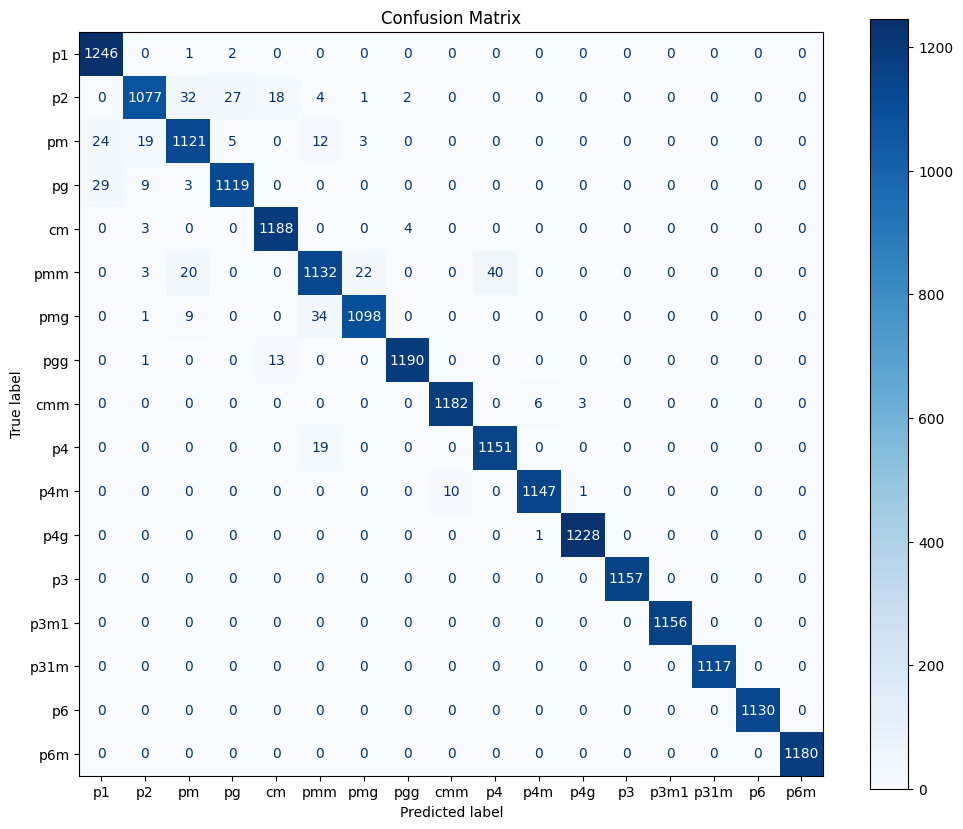

In [11]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=f'{NAME}-train', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [12]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(f'{NAME}-cross_validation_cm.npy', cm)

  0%|          | 0/167 [00:00<?, ?it/s]

100%|██████████| 167/167 [01:00<00:00,  2.77it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,5947.0,5912.0,5900.0,5870.0,5866.0,5966.0,5851.0,5819.0,5897.0,5893.0,5773.0,5902.0,5914.0,5856.0,5908.0,5788.0,5938.0


Accuracy for these batches: 0.06849


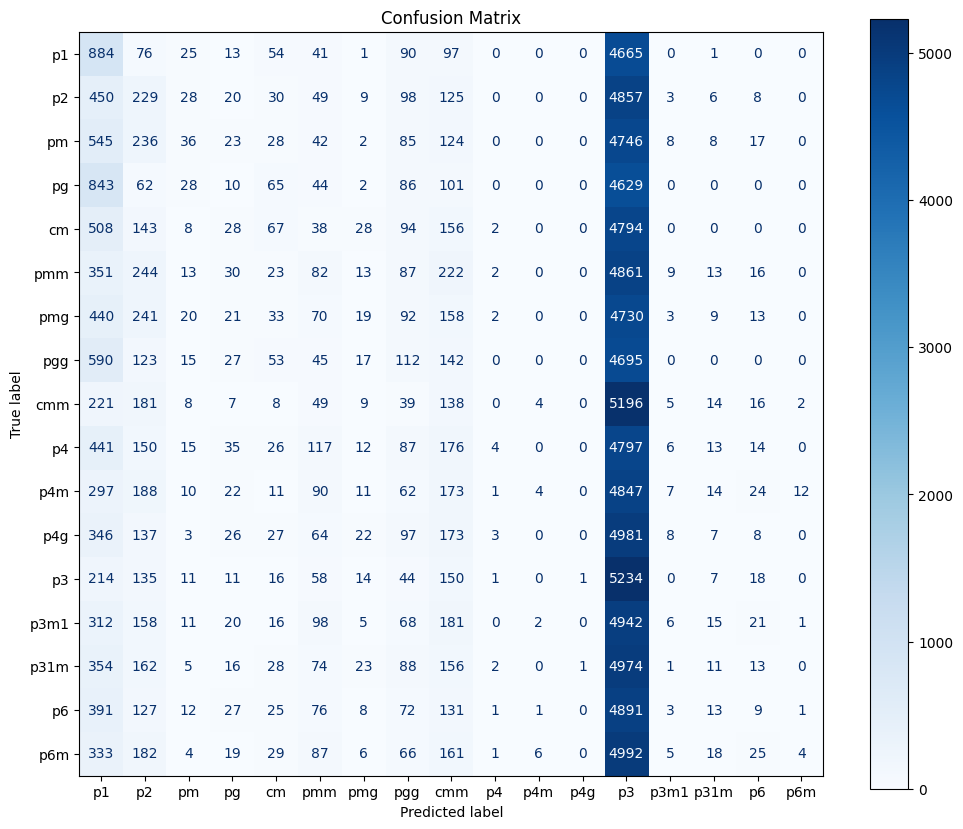

In [13]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=f'{NAME}-cross_validation', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')